<a href="https://colab.research.google.com/github/junsookim76/Ewha_2026/blob/main/3_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plot using the **matplotlib** library

In [1]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline


matplotlib.rcParams.update(matplotlib.rcParamsDefault)

## **1. Sin & Cos**

In [2]:
x = np.arange(0,4*np.pi,0.1)   # start,stop,step
y = np.sin(x)
z = np.cos(x)


In [3]:
print(x.shape)
print(y.shape)
print(z.shape)
print(x[:10])
print(y[:10])

(126,)
(126,)
(126,)
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
[0.         0.09983342 0.19866933 0.29552021 0.38941834 0.47942554
 0.56464247 0.64421769 0.71735609 0.78332691]


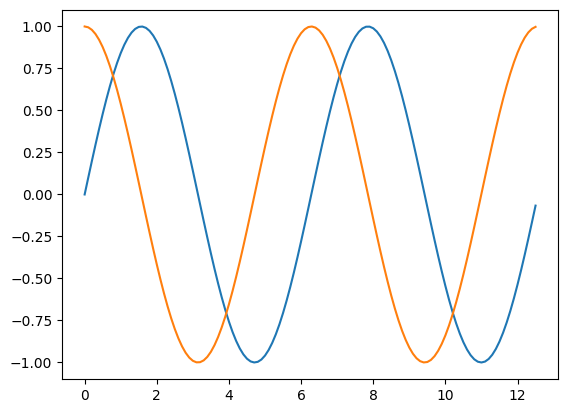

In [4]:
plt.plot(x,y,x,z)
plt.show()

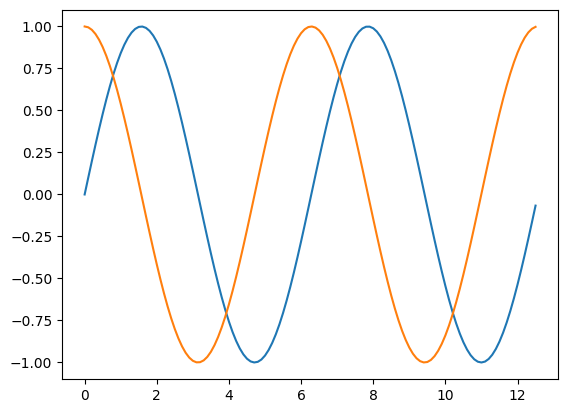

In [5]:
plt.plot(x,y)
plt.plot(x,z)
plt.show()

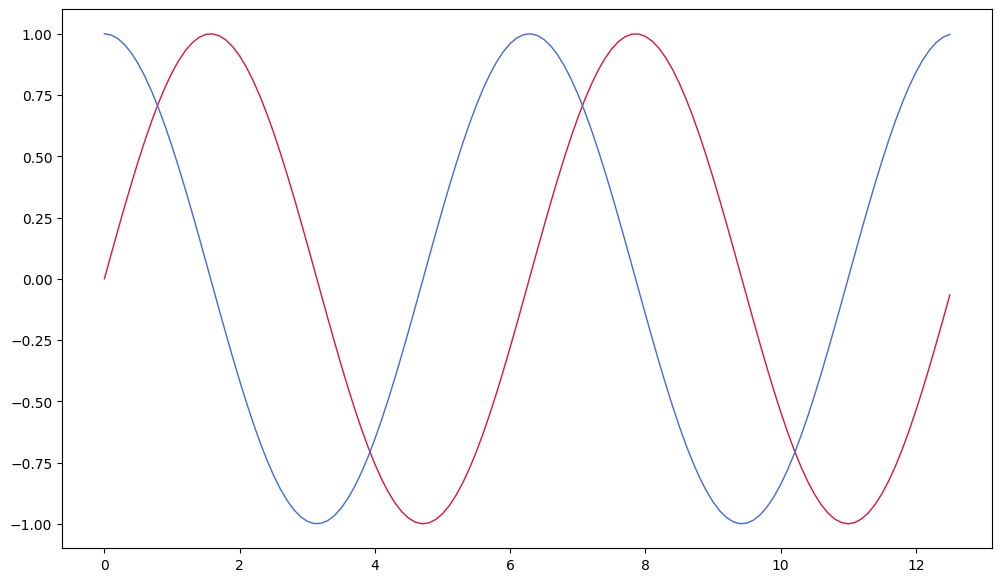

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(x, y, color='crimson', linewidth=1)
ax.plot(x, z, color='royalblue', linewidth=1)

plt.show()

<Figure size 640x480 with 0 Axes>

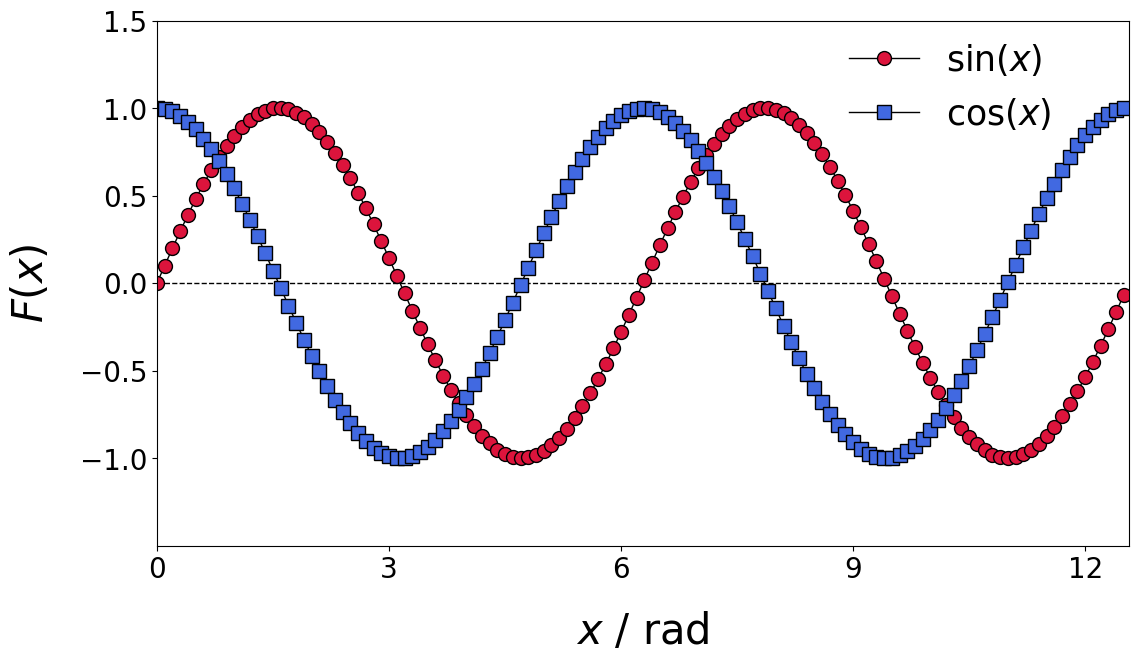

In [8]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('axes', labelsize=30)

fig, ax = plt.subplots(figsize=(12, 7))

y0=np.zeros(len(x))

ax.plot(x,y0,'k--',linewidth=1)
ax.plot(x, y, label='sin$(x)$', color='black', linewidth=1,\
        marker='o', markersize=10, markeredgewidth=1, markeredgecolor='black', mfc='crimson')
ax.plot(x, z, label='cos$(x)$', color='black', linewidth=1,\
        marker='s', markersize=10, markeredgewidth=1, markeredgecolor='black', mfc='royalblue')

ax.set_xlabel('$x$ / rad', labelpad=20)
ax.set_ylabel('$F(x)$', labelpad=20)

ax.set_xlim(0, 4*np.pi)
ax.set_ylim(-1.50, 1.50)

ax.set_xticks(np.arange(0., 13, 3))
ax.set_yticks(np.arange(-1., 1.81, 0.5))

ax.legend(edgecolor='none',bbox_to_anchor=(0.68,0.73), prop={'size': 25})

plt.gcf().subplots_adjust(bottom=0.2)
plt.gcf().subplots_adjust(top=0.95)
plt.gcf().subplots_adjust(left=0.14)
plt.gcf().subplots_adjust(right=0.95)

plt.savefig("data_plot_sin_cos.pdf")

plt.show()

# "/content/data_plot_sin_cos.pdf"를 다운로드 하세요.

## **2. Data Fitting: Linear**

In [ ]:
!git clone https://github.com/junsookim76/Ewha_2026.git

In [ ]:
data1 = np.loadtxt("Ewha_2026/data_AT.txt")
data2 = np.loadtxt("Ewha_2026/data_AC.txt")

print(data1.shape)
print(data2.shape)

print(data1)
print(data2)


In [ ]:
xdata1 = data1[:,0]
ydata1 = data1[:,1]

xdata2 = data2[:,0]
ydata2 = data2[:,1]

print(xdata1.shape)
print(xdata1)

print(ydata1.shape)
print(ydata1)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

x0=np.array([-100,100])
y0=np.array([0,0])

ax.plot(x0,y0,'k--',linewidth=1)

ax.plot(xdata1, ydata1, label='AT', color='black', linewidth=0,\
         marker='o', markersize=15, markeredgewidth=1, markeredgecolor='black', mfc='crimson')
ax.plot(xdata2, ydata2, label='AC', color='black', linewidth=0,\
         marker='s', markersize=15, markeredgewidth=1, markeredgecolor='black', mfc='royalblue')


ax.set_xlabel('$x$', labelpad=20)
ax.set_ylabel('$F(x)$', labelpad=20)

ax.set_xlim(6, 18)
ax.set_ylim(-40, 10)

ax.set_xticks(np.arange(7, 19, 2))
ax.set_yticks(np.arange(-40., 12, 10))

plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('axes', labelsize=30) # fontsize of the x and y labels

ax.legend(edgecolor='none',bbox_to_anchor=(0.85,0.4), prop={'size': 25})

plt.gcf().subplots_adjust(bottom=0.2)
plt.gcf().subplots_adjust(top=0.95)
plt.gcf().subplots_adjust(left=0.14)
plt.gcf().subplots_adjust(right=0.95)

plt.show()

plt.savefig("data_plot_AT_AC.pdf")

# "/content/data_plot_sin_cos.pdf"를 다운로드 하세요.


In [ ]:
from scipy.optimize import curve_fit

def func(x, a0, a1):
    return a0*x+a1

# Linear curve fitting
popt1, pcov1 = curve_fit(func, xdata1, ydata1)

# Calcultate r square value
residuals1 = ydata1 - func(xdata1, *popt1)
ss_res1 = np.sum(residuals1**2)
ss_tot1 = np.sum((ydata1-np.mean(ydata1))**2)
r_squared1 = 1 - (ss_res1 / ss_tot1)

print('\nCurve Fit : y = %.3f*x+%.3f --> R^2 = %.3f' % (popt1[0], popt1[1], r_squared1))

print('\nSlope = %.5f' % (popt1[0]))
print('Intercept = %.5f \n' % (popt1[1]))


In [ ]:
# Linear curve fitting
popt2, pcov2 = curve_fit(func, xdata2, ydata2)

# Calcultate r square value
residuals2 = ydata2 - func(xdata2, *popt2)
ss_res2 = np.sum(residuals2**2)
ss_tot2 = np.sum((ydata2-np.mean(ydata2))**2)
r_squared2 = 1 - (ss_res2 / ss_tot2)

print('\nCurve Fit : y = %.3f*x+%.3f --> R^2 = %.3f' % (popt2[0], popt2[1], r_squared2))

print('\nSlope = %.5f' % (popt2[0]))
print('Intercept = %.5f \n' % (popt2[1]))


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

x0=np.array([-100,100])
y0=np.array([0,0])

ax.plot(x0,y0,'k--',linewidth=1)

ax.plot(xdata1, ydata1, label='AT', color='black', linewidth=0,\
         marker='o', markersize=15, markeredgewidth=1, markeredgecolor='black', mfc='crimson')
ax.plot(xdata2, ydata2, label='AC', color='black', linewidth=0,\
         marker='s', markersize=15, markeredgewidth=1, markeredgecolor='black', mfc='royalblue')
ax.plot(xdata1, func(xdata1, popt1[0], popt1[1]), label=r'$%.5f*x+%.5f$' %(popt1[0],popt1[1]), linewidth= 2, linestyle='--', color='black')
ax.plot(xdata2, func(xdata2, popt2[0], popt2[1]), label=r'$%.5f*x+%.5f$' %(popt2[0],popt2[1]), linewidth= 2, linestyle='-', color='black')


ax.set_xlabel('$x$', labelpad=20)
ax.set_ylabel('$F(x)$', labelpad=20)

ax.set_xlim(6, 18)
ax.set_ylim(-40, 10)

ax.set_xticks(np.arange(7, 19, 2))
ax.set_yticks(np.arange(-40., 12, 10))

plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('axes', labelsize=30) # fontsize of the x and y labels

ax.legend(edgecolor='none',bbox_to_anchor=(0.5,0.45), prop={'size': 25})

plt.gcf().subplots_adjust(bottom=0.2, left=0.14, top=0.95, right=0.95)


plt.savefig("data_plot_AT_AC.pdf")

plt.show()

## Exercise 1. Curve Fitting: Exponential

> 1. GitHub에서 data_exponential.dat라는 파일을 불러 파일에 담긴 데이터를 확인하시오.
>
> 2. 2열에 있는 data1을 그래프로 나타내시오.
>
> 3. data1을 y=exp(-a*x)에 fitting하고 그래프로 나타내시오.